# Modelling of periodic models

This notebook covers the construction of periodic atomistic models: 3D bulk crystals, 2D surfaces and sheets, and 1D nanotubes and nanoribbons. It uses the Atomic Simulation Environment (ASE) together with the Effective Medium Theory (EMT) calculator to both build and optimize these structures.

Periodicity is central to computational materials science. Real materials are not isolated molecules, they are repeating lattices, and the way a model is constructed, which facet is cut, what vacuum is added, which space group is applied, directly determines what physical properties can be computed from it.

This notebook builds that intuition step by step, starting from simple bulk metals and progressing to complex systems like metal-organic frameworks, transition metal dichalcogenides, and curved nanoribbons.The notebook is organized in three blocks following the dimensionality of the target system. Each block introduces relevant ASE functions, shows how to visualize and repeat the unit cell, and in the 3D case, demonstrates how to find the optimal lattice parameter through  a manual energy scan and an automated cell optimizer.

First, we need to install and load our software environment. We will use the Atomic Simulation Environment (ASE) to build, constrain, and optimize our models, along with the `view` function to visualize our atoms. We also import standard data science tools like `pandas`, `numpy`, and `matplotlib`. Please execute these cells to initialize the environment.

In [1]:
######################################################
##-install the necessery packages for this tutorial-##
######################################################

%%capture
!pip install ase

In [2]:
#########################
##-Importing libraries-##
#########################

##-Data
import pandas as pd
import numpy as np

##-ASE - structure building
from ase import Atoms, Atom
from ase.build import bulk, fcc111, fcc100, mx2, surface, graphene, nanotube, graphene_nanoribbon, add_adsorbate
from ase.data import atomic_numbers, chemical_symbols, reference_states
from ase.spacegroup import crystal

##-ASE - I/O and visualization
from ase.io import read, write
from ase.visualize import view

##-ASE - simulation
from ase.optimize import BFGS
from ase.filters import ExpCellFilter

##-Calculator
from ase.calculators.emt import EMT

## 3D Models

### Bulk metals

https://wiki.fysik.dtu.dk/ase/ase/build/build.html#ase.build.bulk

 Let's build a simple 3D metal. The `bulk` function defines our object (Copper, FCC structure). The `a` parameter is the **lattice parameter**, which dictates the overall size of the lattice. We set `orthorhombic=True` so the unit cell is represented clearly as a box with 90-degree angles.


In [3]:
atoms = bulk("Cu", "fcc", a=8, orthorhombic=True)
atoms

Atoms(symbols='Cu2', pbc=True, cell=[5.65685424949238, 5.65685424949238, 8.0])

Since its periodic system, we can repeat it.

The unit cell is the smallest structural unit possessing the properties of the metal. By repeating it (e.g., `2x2x2` or `4x4x4`), you can build a larger model resembling a nanoparticle. Execute to see the atoms and the periodic boundary box.


In [4]:
view(atoms*(2,2,2), viewer ='x3d')

In [5]:
view(atoms*(4,4,4), viewer ='x3d')

ASE has built-in defaults. If you look up Silver (element 47) or Platinum (element 78), ASE already knows their default FCC symmetries and lattice parameters (like 4.09 for Ag), meaning you can generate them without manually typing the parameters.


In [6]:
print(f"{chemical_symbols[47]}, {reference_states[47]}")

Ag, {'symmetry': 'fcc', 'a': 4.09}


In [7]:
print(f"{chemical_symbols[78]}, {reference_states[78]}")

Pt, {'symmetry': 'fcc', 'a': 3.92}


In [8]:
atoms = fcc111('Pt', (3, 3, 5), a=3.9936, vacuum=10.0)
atoms.pbc = [True, True, True]
view(atoms, viewer ='x3d')

### *Calculation*

For calculations we will use the Effective Medium Potential (EMT):

https://wiki.fysik.dtu.dk/ase/ase/calculators/emt.html

Cell optimization (manual) aka Equation of state:

https://wiki.fysik.dtu.dk/ase/tutorials/eos/eos.html

How do we find the optimal distance between atoms? In solid-state physics, an "Equation of State" relates volume (lattice parameter) to energy. We will use an Effective Medium Potential (EMT) calculator to describe atomic interactions. This code runs a loop of 100 calculations on Silver with varying lattice sizes and saves the energies to a dataframe.


In [9]:
%%capture

df = pd.DataFrame(columns=['a', 'energy'])

for a in np.linspace(3.8,4.4, 100):
  atoms = bulk('Ag', a=a)
  calc = EMT()
  atoms.calc = calc
  energy = atoms.get_potential_energy()
  new_row = pd.DataFrame({'a': [a], 'energy': [energy]})
  df = pd.concat([df, new_row], ignore_index=True)

In [10]:
df

,a,energy
0,3.800000,0.251280
1,3.806061,0.238609
2,3.812121,0.226330
3,3.818182,0.214434
4,3.824242,0.202913
...,...,...
95,4.375758,0.213044
96,4.381818,0.220404
97,4.387879,0.227836
98,4.393939,0.235332


Plot the resulting dataframe. At the minimum optimal energy, the curve should resemble a parabolic shape.

<Axes: xlabel='Cell parameter / Å', ylabel='Energy per atom / eV'>

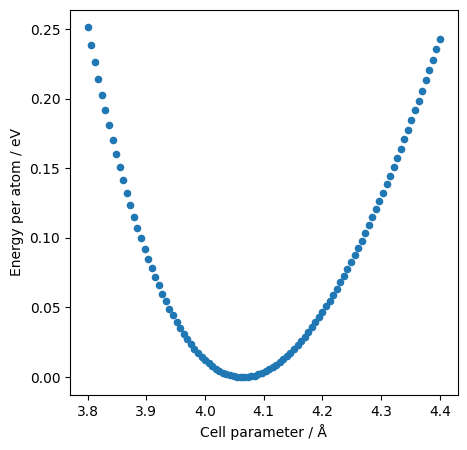

In [11]:
df.plot.scatter(
    x='a',
    y='energy',
    xlabel='Cell parameter / Å',
    ylabel='Energy per atom / eV',
    figsize=(5, 5)

    )

Cell optimization (with ASE function) with a sophisticated algorithm:

https://wiki.fysik.dtu.dk/ase/ase/filters.html#ase.filters.ExpCellFilter

 Instead of calculating 100 points manually, you can use an optimization algorithm. The `ExpCellFilter` mathematically adjusts the cell parameters to find the exact optimal distance by minimizing the forces until a max threshold (e.g., 0.1) is reached.


In [12]:
%%capture

atoms = bulk('Ag')
calc = EMT()
atoms.calc = calc
opt = BFGS(ExpCellFilter(atoms), trajectory='opt.Ag.traj')
opt.run(fmax=0.1)

In [13]:
print(f"Optimized cell parameter a: {atoms.cell[0][2]*2:.2f}")
view(atoms*3, viewer ='x3d')

Optimized cell parameter a: 4.06


### Halides and oxides

The ASE function for bulk structure creation include the following structures

 https://wiki.fysik.dtu.dk/ase/_modules/ase/build/bulk.html#bulk:
```
structures = {'sc': 1, 'fcc': 1, 'bcc': 1,
                  'tetragonal': 1,
                  'bct': 1,
                  'hcp': 1,
                  'rhombohedral': 1,
                  'orthorhombic': 1,
                  'mcl': 1,
                  'diamond': 1,
                  'zincblende': 2, 'rocksalt': 2, 'cesiumchloride': 2,
                  'fluorite': 3, 'wurtzite': 2}
```

ASE contains many specific unit cells. This generates a "rock salt" (NaCl) crystal. Try rotating the 3D viewer until you see how the atoms form alternating cubic and square planes.


In [14]:
##-NaCl crystal
atoms = bulk("NaCl", "rocksalt", 5.63)
view(atoms*(9,9,3), viewer ='x3d')


https://wiki.fysik.dtu.dk/ase/ase/spacegroup/spacegroup.html#module-ase.spacegroup

For more complex solids, we use **Space Groups** (like 136 for Rutile Titanium Oxide), which describe the internal symmetry and specific atomic positions of the crystal.


In [15]:
##-TiO₂ crystal

atoms = crystal(
    ['Ti', 'N'],
    basis=[(0, 0, 0), (0.3, 0.3, 0.0)],
    spacegroup=136,
    cellpar=[4.6, 4.6, 2.95, 90, 90, 90]
    )

view(atoms*(3,3,4), viewer ='x3d')

You can verify your generated structures against real-world data. These cells use `wget` to download an actual `.cif` (Crystallographic Information File) from the American Mineralogist Crystal Structure Database so you can compare it.


In [16]:
!wget https://raw.githubusercontent.com/cryos/avogadro/refs/heads/master/crystals/oxides/TiO2-Rutile.cif

--2026-06-22 10:20:46--  https://raw.githubusercontent.com/cryos/avogadro/refs/heads/master/crystals/oxides/TiO2-Rutile.cif
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2191 (2.1K) [text/plain]
Saving to: ‘TiO2-Rutile.cif’

TiO2-Rutile.cif     100%[===================>]   2.14K  --.-KB/s    in 0s      

2026-06-22 10:20:46 (33.5 MB/s) - ‘TiO2-Rutile.cif’ saved [2191/2191]



In [17]:
atoms = read("TiO2-Rutile.cif")
view(atoms*(3,3,4), viewer ='x3d')

### Metal organic frameworks

Example, custom MOF based on changing linker:

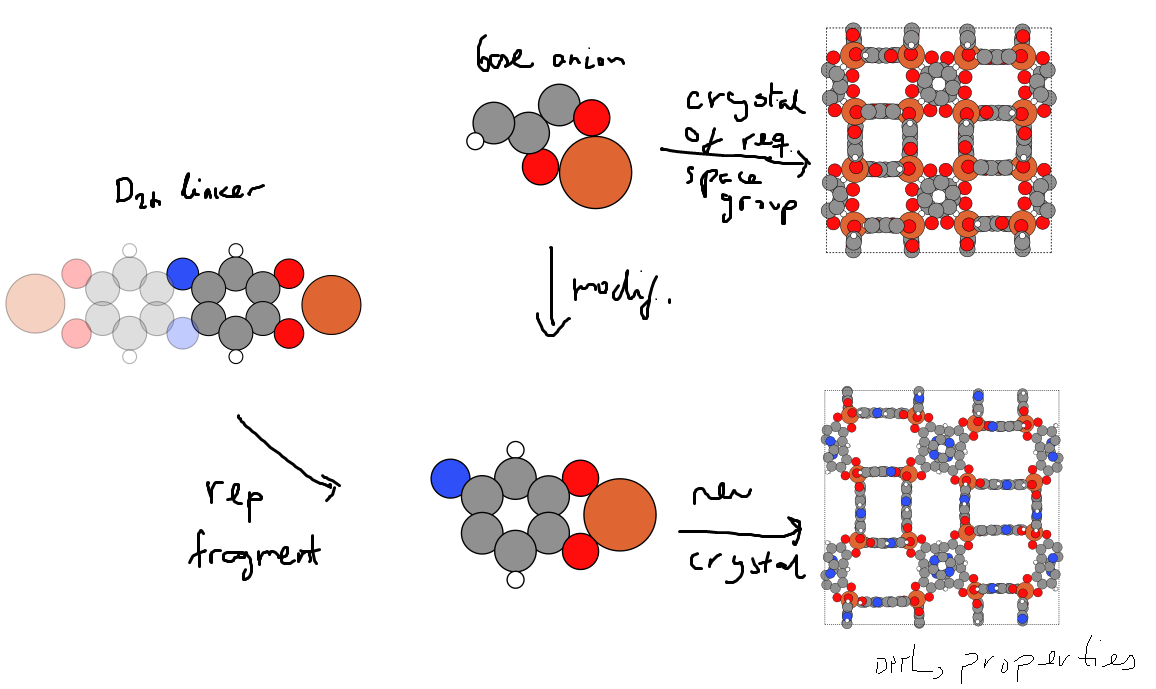


MOFs have complex, repeating semi-organic structures. These text blocks define the coordinates for a base piece, such as an iron-based fragment, and write them to `.xyz` files.


In [18]:
atoms = """13
Fe2_phenazine_half
O        4.75660000       1.33840000      -0.38000000      -0.36000000
O        4.75640000      -1.33870000       0.37940000      -0.36000000
N       -0.00010000       1.32510000      -0.37490000      -0.62000000
C        1.15860000       0.67300000      -0.19020000       0.31000000
C        1.15860000      -0.67280000       0.19080000       0.31000000
C        2.37480000       1.32720000      -0.37540000      -0.15000000
C        2.37490000      -1.32700000       0.37620000      -0.15000000
C        3.58800000       0.66730000      -0.18840000       0.08000000
C        3.58800000      -0.66690000       0.18940000       0.08000000
H        2.37960000       2.37450000      -0.67310000       0.15000000
H        2.37960000      -2.37440000       0.67360000       0.15000000
Fe       6.20000000       0.00000000       0.00000000       0.00000000
Fe      -6.20000000       0.00000000       0.00000000       0.00000000
"""

with open("Fe2_phenazine_half.xyz", "w") as text_file:
    text_file.write(atoms)

atoms = """7
Anion
Fe        13.77513       13.77513       13.77513
O         13.63387       15.77482       13.82649
O         11.75861       13.98369       13.66487
C         12.44716       16.24419       13.78664
C         11.32466       15.21910       13.72908
C         10.05161       15.58442       13.76229
H          9.37190       14.92021       13.77114
"""
with open("anion.xyz", "w") as text_file:
    text_file.write(atoms)

In [19]:
# Read in fragments
half_Fe2 = read("Fe2_phenazine_half.xyz")
view(half_Fe2[:-1], viewer ='x3d')

In [20]:
anion = read("anion.xyz") # reference anion
view(anion, viewer ='x3d')

In [21]:
##-Define IDs for which is center Fe and which is used to set axis
Fe_center_ID = 11
Fe_helper_ID = 12
##-Center the molecule on Fe center
half_Fe2.positions -= half_Fe2[11].position
##-Rotate the molecule so that Fe-Fe vector lies on (-1, 1, 0) vector
half_Fe2.rotate(half_Fe2.positions[12],[-1, 1, 0])

##-put the anion in cell
half = half_Fe2[0:Fe_center_ID+1]

##-Scale the cell by Fe-Fe distances so that special equivalent points of 220 space group are correct
cell_par = np.sqrt(2)*2*np.linalg.norm(half_Fe2.positions[Fe_helper_ID]-half_Fe2.positions[Fe_center_ID])
half.cell=[cell_par, cell_par, cell_par]
##-Move the Fe-center so that it lies in very specific position which yields nice symmetrical arrangement,
##-as taken from reference crystal
half.positions += anion.positions[0]*cell_par/22.1401

##-Make the crystal
test_crystal2 = crystal(half, spacegroup=220, cellpar=[cell_par, cell_par, cell_par, 90,90,90])
view(test_crystal2, viewer ='x3d')

## 2D Models

### Metal surfaces

https://wiki.fysik.dtu.dk/ase/ase/build/surface.html

We can create 2D metal surfaces by "cutting" a specific facet out of a 3D crystal, such as an FCC 111 face for Aluminum or an FCC 100 face for Platinum. Notice the `vacuum=10.0` parameter, which adds empty space above the 2D plane.


In [22]:
slab = fcc111('Al', size=(2,2,4), vacuum=10.0)
slab

Atoms(symbols='Al16', pbc=[True, True, False], cell=[[5.727564927611035, 0.0, 0.0], [2.8637824638055176, 4.960216729135935, 0.0], [0.0, 0.0, 27.014805770653954]], tags=...)

In [23]:
view(slab, viewer ='x3d')

In [24]:
view(slab*(4,4,1), viewer ='x3d')

In [25]:
slab = fcc100('Pt', size=(2,2,4), vacuum=10.0)
view(slab*(4,4,1), viewer ='x3d')

In [26]:
slab = mx2("MoS2", size=(8,8,1), vacuum=10)
view(slab, viewer ='x3d')

You can use the `add_adsorbate` function to place an external atom (like Hydrogen) on top of the cut surface.

In [27]:
slab = fcc111('Al', size=(2,2,3))
add_adsorbate(slab, 'H', 1.5, 'ontop')
slab.center(vacuum=10.0, axis=2)
view(slab, viewer ='x3d')

### Calculation



Calculate the adsorption energy of oxygen on a metal slab using the EMT calculator. To solve this, run three separate EMT calculations: 1) the slab with oxygen, 2) the slab without oxygen, and 3) the oxygen without the slab. Combine these values to find the specific adsorption energy.

### Custom surfaces

Arbitrary facet

In [28]:
atoms = fcc111('Pt', (3, 3, 5), a=3.9936, vacuum=10.0)
view(slab*(2,8,1), viewer ='x3d')

Alloy surfaces

In [29]:
a = 4.0
Pt3Rh = Atoms(
    'Pt3Rh',
    scaled_positions=[(0, 0, 0), (0.5, 0.5, 0), (0.5, 0, 0.5), (0, 0.5, 0.5)],
    cell=[a, a, a],
    pbc=True
    )

s1 = surface(Pt3Rh, (2, 1, 1), 9)
s1.center(vacuum=10, axis=2)
view(s1*(2,3,1), viewer ='x3d')

In [30]:
Pt3Rh.set_chemical_symbols('PtRhPt2')
s2 = surface(Pt3Rh, (2, 1, 1), 9)
s2.center(vacuum=10, axis=2)
view(s2*(2,3,1), viewer ='x3d')

### Non-metal 2D surfaces

Graphene

Run these to visualize true single-plane 2D materials. You will see Graphene, Boron Nitride (where Boron and Nitrogen replace Carbon), and Bismuthene, which is unique because it is a 2D metallic sheet.


In [31]:
graphene_sheet = graphene(formula='C2', a=2.46, size=(4, 4, 1), vacuum=3)
view(graphene_sheet, viewer ='x3d')

Boron Nitride

In [42]:
boronnitride_sheet = graphene(formula='BN', a=2.49, size=(4, 4, 1), vacuum=3)
view(boronnitride_sheet, viewer ='x3d')

Bismuthene

In [44]:
da = 4.48
dl = 1.51
bismuthene_sheet = Atoms(
    [Atom('Bi', (0.0000, 0.0000, -dl)), Atom('Bi', (da/2, np.sqrt(3)*da/6, 0.0))],
    cell=((da,0,0), (da/2,np.sqrt(3)*da/2,0), (0,0,1)),
    pbc=[True,True,False]
    )

bismuthene_sheet.center(axis=2, vacuum=4)
# Visualize the bismuthene structure
view(bismuthene_sheet*(4,4,1), viewer ='x3d')

## 1D Models

### Nanotubes

Nanotubes are one-dimensional cylinders. These cells visualize different structural configurations (sometimes called "chair" or "armchair") repeating along the X and Y axes.

In [45]:
cnt1 = nanotube(6, 0, length=4)
view(cnt1, viewer ='x3d')

In [46]:
cnt2 = nanotube(6, 2, length=1)
view(cnt2, viewer ='x3d')

In [47]:
cnt3 = nanotube(3, 3, length=6, bond=1.4, symbol='N')
view(cnt3, viewer ='x3d')

### Nanoribbons

A nanoribbon is a flat, 1D slice cut from a graphene sheet. If you curl it into a cylinder, it becomes a nanotube. This final custom Python function demonstrates a rare use of sines and cosines in chemistry, mathematically applying a curvature radius to transition the model from a flat ribbon to a curved tube.

In [48]:
gnr1 = graphene_nanoribbon(3, 4, type='armchair', saturated=True, vacuum=3.5)
view(gnr1, viewer ='x3d')

In [38]:
def createBase(curve=True):
  atoms = graphene_nanoribbon(3.5, 2, saturated='True', type='armchair')  # Create nanoribbon
  center_pos = (atoms[11].position + atoms[12].position) / 2  # Calculate center position
  for atom in atoms:
    atom.position[0] -= center_pos[0]  # Center all atoms along x-axis
  atoms.center()  # Center atoms if curved

  if curve:
    atoms.center()  # Center atoms if curved
  else:
    atoms.center(vacuum=8, axis=(0, 1))  # Center with vacuum for non-curved

  atoms.pbc = [False, False, True]  # Set periodic boundary conditions
  return atoms  # Return atoms object

def createCurvature(atoms, r):
  for atom in atoms:
    theta = atom.position[0] / r  # Calculate curvature angle
    atom.position[0], atom.position[1] = r * np.sin(theta), -r * np.cos(theta)  # Curve positions

  atoms.center(vacuum=8, axis=(0, 1))  # Center with vacuum
  return atoms  # Return atoms object

In [49]:
view(createBase(False), viewer ='x3d')

In [51]:
view(createCurvature(createBase(), 20), viewer ='x3d')

In [52]:
view(createCurvature(createBase(), 4), viewer ='x3d')

## Summary

After completing this notebook, you should be able to:

1. Build bulk crystals using bulk() with common symmetries (FCC, BCC, rocksalt, diamond, and others), repeat unit cells to construct larger supercells, and use ASE's built-in reference data to look up default lattice parameters for elements. Build more complex crystals, including oxides and MOFs, using space group symmetry via crystal() and import external structures from CIF files.
Cell optimization. Find the equilibrium lattice parameter of a metal either by scanning a range of values manually and plotting the resulting energy curve, or by using the ExpCellFilter with a BFGS optimizer to converge directly to the minimum.

2. Cut metal surfaces from bulk crystals at specific facets using fcc111(), fcc100(), and the general surface() function. Add vacuum layers, place adsorbates with add_adsorbate(), and build alloy surfaces by manually setting atomic symbols on a shared lattice. Generate non-metal 2D sheets including graphene, hexagonal boron nitride, and custom materials like bismuthene defined from scratch.


3. Build carbon nanotubes with different chiral indices using nanotube(), generate armchair and zigzag graphene nanoribbons with graphene_nanoribbon(), and apply a mathematical curvature transformation using sine and cosine to roll a flat nanoribbon into a tube geometry.